## 3.1 난수 좌표 생성:
[0, 1) 범위에서 100개의 2차원 좌표를 생성.

In [57]:
import numpy as np

x = np.random.rand(100,2)
x.shape

(100, 2)

## 3.2 거리 행렬 계산:
각 점 간의 유클리드 거리 제곱을 계산하여 100x100 크기의 거리 행렬을 생성.

In [58]:
x[:, None, :].shape, x[None, :, :].shape

((100, 1, 2), (1, 100, 2))

In [59]:
dist_sq = np.sum((x[:, None, :] - x[None, :, :])**2, axis=1)
dist_sq.shape

(100, 2)

In [60]:
dif = x[:, None, :] - x[None, :, :]
dif.shape
sq_dif = dif **2
sq_dif.shape
dist_sq = sq_dif.sum(-1)
dist_sq.shape

(100, 100)

## 3.3 5-최근접 이웃 찾기:
각 점에 대해 가장 가까운 5개의 점을 거리 순으로 정렬.
자기 자신을 제외하고 가장 가까운 5개의 이웃.

In [61]:
nearest = np.argsort(dist_sq, axis=1)
nearest

k = 2
near_part = np.argpartition(dist_sq, k+1, axis=1)
near_part

array([[ 0, 59, 96, ..., 97, 98, 49],
       [38,  1,  5, ..., 97,  9, 99],
       [ 2, 46, 29, ..., 97,  3, 49],
       ...,
       [97, 73, 67, ...,  2, 98, 49],
       [86, 98, 44, ..., 97,  3, 49],
       [99, 11,  9, ...,  2, 98, 49]], dtype=int64)

## 3.4 결과 출력:
각 점에 대해 가장 가까운 5개의 이웃의 좌표와 거리 제곱을 출력.

## 3.5 시각화:
matplotlib를 사용하여 각 점과 해당 점의 5-최근접 이웃을 플롯.
각 점은 scatter로 표시하고, 가까운 이웃과 연결하는 선을 추가하여 관계를 시각적으로 표현.

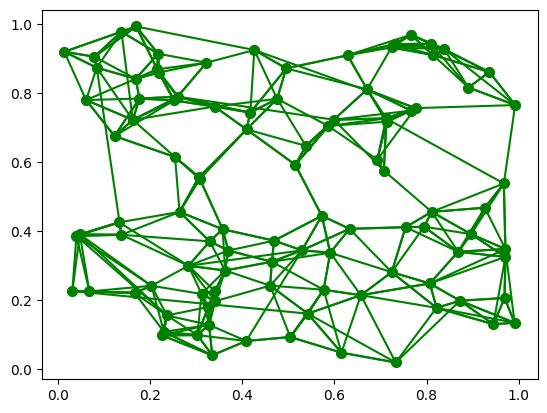

In [70]:
import matplotlib.pyplot as plt
plt.scatter(x[:, 0], x[:, 1], s=50, color='green')
k=5
for i in range(x.shape[0]):
    for j in near_part[i, :k+1]:
        plt.plot(*zip(x[j], x[i]), color='green')